In [ ]:
!pip install transformers datasets evaluate accelerate scikit-learn matplotlib seaborn -q
print("Installation complete!")

Installation complete!


In [ ]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
from collections import defaultdict

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import load_dataset
import evaluate

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
MAX_LEN = 512
BATCH_SIZE = 32
EPOCHS = 3

SUBSET_TRAIN = None
SUBSET_TEST = None

MODEL_NAMES = [
    "distilbert-base-uncased",
    "bert-base-uncased",
]

DISPLAY_NAMES = {
    "distilbert-base-uncased": "DistilBERT",
    "bert-base-uncased": "BERT-base",
}

COLORS = {
    "distilbert-base-uncased": "#4C72B0",
    "bert-base-uncased": "#DD8452",
}

print(f"Device: {DEVICE}")
print(f"Training samples per model: {SUBSET_TRAIN or '25,000 (full)'}, Test: {SUBSET_TEST or '25,000 (full)'}")
os.makedirs("figures", exist_ok=True)

Device: cuda
Training samples per model: 25,000 (full), Test: 25,000 (full)


In [ ]:
print("Loading IMDb dataset from HuggingFace...")
raw_dataset = load_dataset("imdb")
print(raw_dataset)

if SUBSET_TRAIN:
    train_raw = raw_dataset["train"].shuffle(seed=SEED).select(range(SUBSET_TRAIN))
else:
    train_raw = raw_dataset["train"].shuffle(seed=SEED)

if SUBSET_TEST:
    test_raw = raw_dataset["test"].shuffle(seed=SEED).select(range(SUBSET_TEST))
else:
    test_raw = raw_dataset["test"].shuffle(seed=SEED)

print(f"\nUsing {len(train_raw)} training samples, {len(test_raw)} test samples")
print("Label distribution (train):")
from collections import Counter
print(Counter(train_raw["label"]))

Loading IMDb dataset from HuggingFace...
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Using 25000 training samples, 25000 test samples
Label distribution (train):
Counter({1: 12500, 0: 12500})


In [ ]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)


def tokenize_dataset(model_name, train_data, test_data):
    """Tokenize train/test splits for a given model."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_fn(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_LEN,
            padding="max_length",
        )

    cols_to_keep = ["input_ids", "attention_mask", "labels"]

    train_tok = train_data.map(tokenize_fn, batched=True, desc="Tokenizing train")
    test_tok = test_data.map(tokenize_fn,  batched=True, desc="Tokenizing test")

    train_tok = train_tok.rename_column("label", "labels")
    test_tok = test_tok.rename_column("label", "labels")

    train_tok.set_format("torch", columns=cols_to_keep)
    test_tok.set_format("torch",  columns=cols_to_keep)

    return tokenizer, train_tok, test_tok


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def get_model_size_mb(model):
    param_bytes = sum(p.nelement() * p.element_size() for p in model.parameters())
    buffer_bytes = sum(b.nelement() * b.element_size() for b in model.buffers())
    return (param_bytes + buffer_bytes) / 1024**2


def benchmark_inference(model, tokenizer, sample_texts, n_runs=200):
    """Returns mean latency in milliseconds (batch size = 1, on DEVICE)."""
    model.eval()
    model.to(DEVICE)
    inputs = tokenizer(
        sample_texts[:1],
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        for _ in range(20):
            model(**inputs)

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_runs):
            model(**inputs)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    return (elapsed / n_runs) * 1000  # ms


print("Helper functions defined.")

Helper functions defined.


In [ ]:
all_results = {}
trained_models = {}
tokenizers = {}

for model_name in MODEL_NAMES:
    display = DISPLAY_NAMES[model_name]
    print(f"\n{'='*60}")
    print(f"  Training: {display} ({model_name})")
    print(f"{'='*60}")

    tokenizer, train_tok, test_tok = tokenize_dataset(model_name, train_raw, test_raw)
    tokenizers[model_name] = tokenizer

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    n_params  = count_parameters(model)
    size_mb   = get_model_size_mb(model)

    training_args = TrainingArguments(
        output_dir=f"./ckpt/{model_name.replace('/', '_')}",
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        seed=SEED,
        report_to="none",
        fp16=torch.cuda.is_available(),
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        compute_metrics=compute_metrics,
    )

    t0 = time.perf_counter()
    trainer.train()
    train_time_sec = time.perf_counter() - t0

    eval_results = trainer.evaluate()
    accuracy = eval_results["eval_accuracy"]

    sample_texts = [raw_dataset["test"][0]["text"]]
    latency_ms = benchmark_inference(model, tokenizer, sample_texts)

    all_results[model_name] = {
        "accuracy": accuracy,
        "n_params": n_params,
        "size_mb": size_mb,
        "train_time_sec": train_time_sec,
        "latency_ms": latency_ms,
        "eval_loss": eval_results["eval_loss"],
    }
    trained_models[model_name] = model

    print(f"\n  Accuracy:       {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Parameters:     {n_params/1e6:.1f}M")
    print(f"  Model size:     {size_mb:.1f} MB")
    print(f"  Train time:     {train_time_sec/60:.1f} min")
    print(f"  Inference:      {latency_ms:.2f} ms/sample")

print("\n" + "="*60)
print("All models trained!")


  Training: DistilBERT (distilbert-base-uncased)


Tokenizing train:   0%|          | 0/25000 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/25000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Tokenizing test:   0%|          | 0/25000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

Epoch,Training Loss,Validation Loss,Accuracy
1,0.298904,0.192021,0.933480
2,0.139407,0.173786,0.936360
3,0.072081,0.230946,0.941080



  Accuracy:       0.9411 (94.11%)
  Parameters:     109.5M
  Model size:     417.7 MB
  Train time:     38.6 min
  Inference:      12.46 ms/sample

All models trained!


In [ ]:
distil = all_results["distilbert-base-uncased"]
bert = all_results["bert-base-uncased"]

param_reduction = (1 - distil["n_params"] / bert["n_params"]) * 100
size_reduction = (1 - distil["size_mb"]  / bert["size_mb"])  * 100
speedup_factor = bert["latency_ms"] / distil["latency_ms"]
acc_retention = distil["accuracy"] / bert["accuracy"] * 100
train_speedup = bert["train_time_sec"] / distil["train_time_sec"]

print("="*70)
print(f"{'Metric':<28} {'DistilBERT':>14} {'BERT-base':>14} {'Difference':>12}")
print("-"*70)
print(f"{'Test Accuracy':<28} {distil['accuracy']*100:>13.2f}% {bert['accuracy']*100:>13.2f}% {(distil['accuracy']-bert['accuracy'])*100:>+11.2f}%")
print(f"{'Parameters':<28} {distil['n_params']/1e6:>11.1f}M   {bert['n_params']/1e6:>11.1f}M   {-param_reduction:>+10.1f}%")
print(f"{'Model Size (MB)':<28} {distil['size_mb']:>13.1f} {bert['size_mb']:>13.1f} {-size_reduction:>+10.1f}%")
print(f"{'Inference Latency (ms)':<28} {distil['latency_ms']:>13.2f} {bert['latency_ms']:>13.2f} {speedup_factor:>10.2f}x faster")
print(f"{'Training Time (min)':<28} {distil['train_time_sec']/60:>13.1f} {bert['train_time_sec']/60:>13.1f} {train_speedup:>10.2f}x faster")
print("="*70)
print(f"\nDistilBERT retains {acc_retention:.1f}% of BERT accuracy")
print(f"DistilBERT has {param_reduction:.1f}% fewer parameters")
print(f"DistilBERT is {speedup_factor:.1f}x faster at inference")
print(f"\nPaper claims: 97% accuracy retention, 40% fewer params, 60% faster")

Metric                           DistilBERT      BERT-base   Difference
----------------------------------------------------------------------
Test Accuracy                        93.06%         94.11%       -1.05%
Parameters                          67.0M         109.5M        -38.8%
Model Size (MB)                      255.4         417.7      -38.8%
Inference Latency (ms)                6.58         12.46       1.89x faster
Training Time (min)                   19.5          38.6       1.98x faster

DistilBERT retains 98.9% of BERT accuracy
DistilBERT has 38.8% fewer parameters
DistilBERT is 1.9x faster at inference

Paper claims: 97% accuracy retention, 40% fewer params, 60% faster


In [ ]:
for model_name, model in trained_models.items():
    model_cpu = model.cpu()
    tokenizer = tokenizers[model_name]
    sample = [raw_dataset["test"][0]["text"]]

    original_device = DEVICE
    import types
    latency_cpu = benchmark_inference.__wrapped__(model_cpu, tokenizer, sample) \
        if hasattr(benchmark_inference, '__wrapped__') else None

    inputs = tokenizer(sample, return_tensors="pt", truncation=True,
                       max_length=MAX_LEN, padding="max_length")
    model_cpu.eval()
    with torch.no_grad():
        for _ in range(5): model_cpu(**inputs)
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(50): model_cpu(**inputs)
    cpu_latency = (time.perf_counter() - t0) / 50 * 1000
    print(f"{DISPLAY_NAMES[model_name]} CPU latency: {cpu_latency:.1f} ms")

DistilBERT CPU latency: 481.9 ms
BERT-base CPU latency: 953.5 ms


In [ ]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)

models_ordered = ["distilbert-base-uncased", "bert-base-uncased"]
labels = [DISPLAY_NAMES[m] for m in models_ordered]
bar_colors = [COLORS[m] for m in models_ordered]


def save_fig(name):
    plt.tight_layout()
    plt.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: figures/{name}.png")

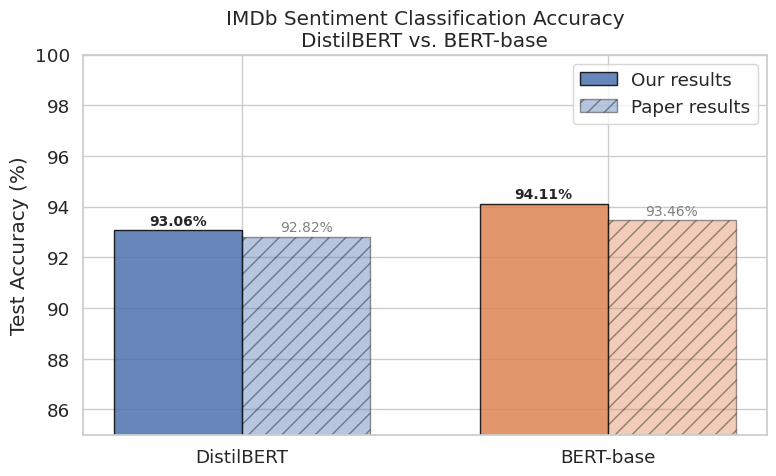

Saved: figures/01_accuracy_comparison.png


In [ ]:
# Test Accuracy
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(labels))
width = 0.35

our_acc = [all_results[m]["accuracy"] * 100 for m in models_ordered]
paper_acc = [92.82, 93.46]  # DistilBERT, BERT-base from Table 2

bars1 = ax.bar(x - width/2, our_acc,   width, label="Our results",   color=bar_colors, alpha=0.85, edgecolor="black")
bars2 = ax.bar(x + width/2, paper_acc, width, label="Paper results", color=bar_colors, alpha=0.4,  edgecolor="black", hatch="//")

ax.set_ylabel("Test Accuracy (%)")
ax.set_title("IMDb Sentiment Classification Accuracy\nDistilBERT vs. BERT-base")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(85, 100)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{bar.get_height():.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{bar.get_height():.2f}%", ha="center", va="bottom", fontsize=10, color="gray")

save_fig("01_accuracy_comparison")

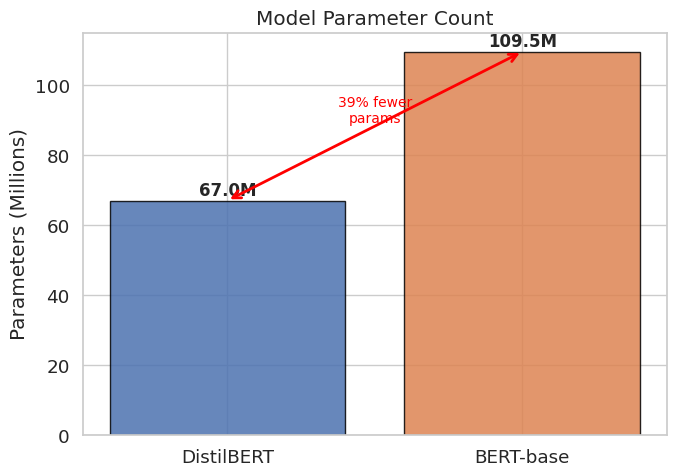

Saved: figures/02_parameter_count.png


In [ ]:
# Parameter Count
fig, ax = plt.subplots(figsize=(7, 5))

params_M = [all_results[m]["n_params"] / 1e6 for m in models_ordered]
bars = ax.bar(labels, params_M, color=bar_colors, edgecolor="black", alpha=0.85)

ax.set_ylabel("Parameters (Millions)")
ax.set_title("Model Parameter Count")

for bar, val in zip(bars, params_M):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}M", ha="center", va="bottom", fontsize=12, fontweight="bold")

# Annotate the reduction
ax.annotate("", xy=(0, params_M[0]), xytext=(1, params_M[1]),
            arrowprops=dict(arrowstyle="<->", color="red", lw=2))
ax.text(0.5, (params_M[0] + params_M[1])/2 + 1,
        f"{param_reduction:.0f}% fewer\nparams",
        ha="center", color="red", fontsize=10)

save_fig("02_parameter_count")

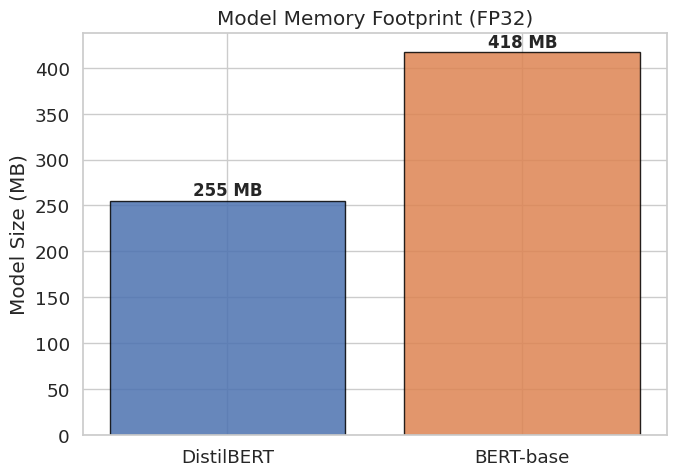

Saved: figures/03_model_size.png


In [ ]:
# Model Size in MB
fig, ax = plt.subplots(figsize=(7, 5))

sizes = [all_results[m]["size_mb"] for m in models_ordered]
bars = ax.bar(labels, sizes, color=bar_colors, edgecolor="black", alpha=0.85)

ax.set_ylabel("Model Size (MB)")
ax.set_title("Model Memory Footprint (FP32)")

for bar, val in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.0f} MB", ha="center", va="bottom", fontsize=12, fontweight="bold")

save_fig("03_model_size")

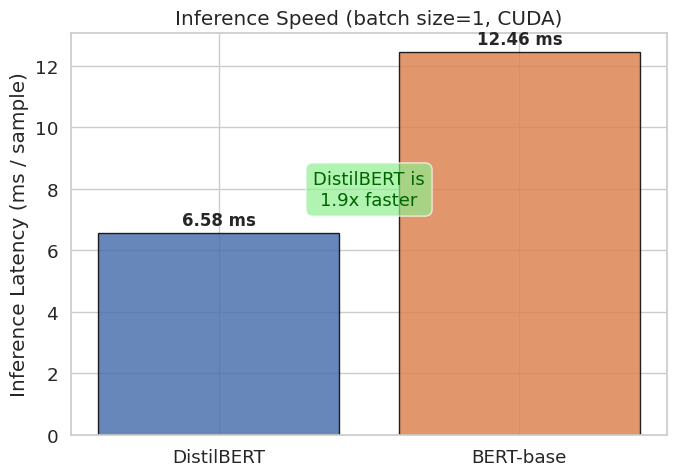

Saved: figures/04_inference_latency.png


In [ ]:
# Inference Latency
fig, ax = plt.subplots(figsize=(7, 5))

latencies = [all_results[m]["latency_ms"] for m in models_ordered]
bars = ax.bar(labels, latencies, color=bar_colors, edgecolor="black", alpha=0.85)

ax.set_ylabel("Inference Latency (ms / sample)")
ax.set_title(f"Inference Speed (batch size=1, {DEVICE.upper()})")

for bar, val in zip(bars, latencies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.2f} ms", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.text(0.5, max(latencies) * 0.6,
        f"DistilBERT is\n{speedup_factor:.1f}x faster",
        ha="center", fontsize=13, color="darkgreen",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="lightgreen", alpha=0.7))

save_fig("04_inference_latency")

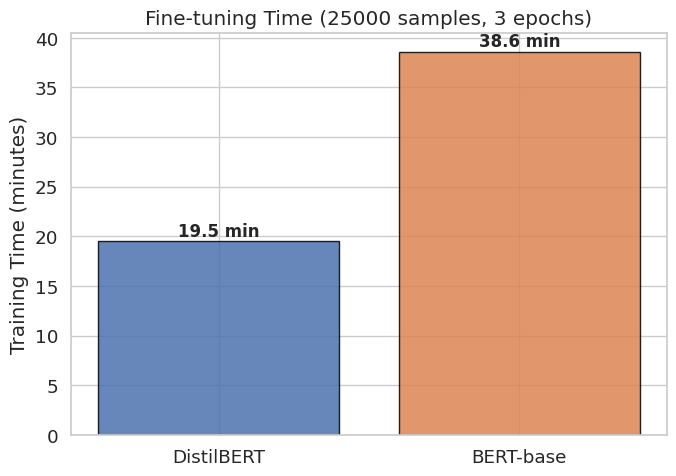

Saved: figures/05_training_time.png


In [ ]:
# Training Time
fig, ax = plt.subplots(figsize=(7, 5))

train_times = [all_results[m]["train_time_sec"] / 60 for m in models_ordered]
bars = ax.bar(labels, train_times, color=bar_colors, edgecolor="black", alpha=0.85)

ax.set_ylabel("Training Time (minutes)")
ax.set_title(f"Fine-tuning Time ({SUBSET_TRAIN or 25000} samples, {EPOCHS} epochs)")

for bar, val in zip(bars, train_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.1f} min", ha="center", va="bottom", fontsize=12, fontweight="bold")

save_fig("05_training_time")

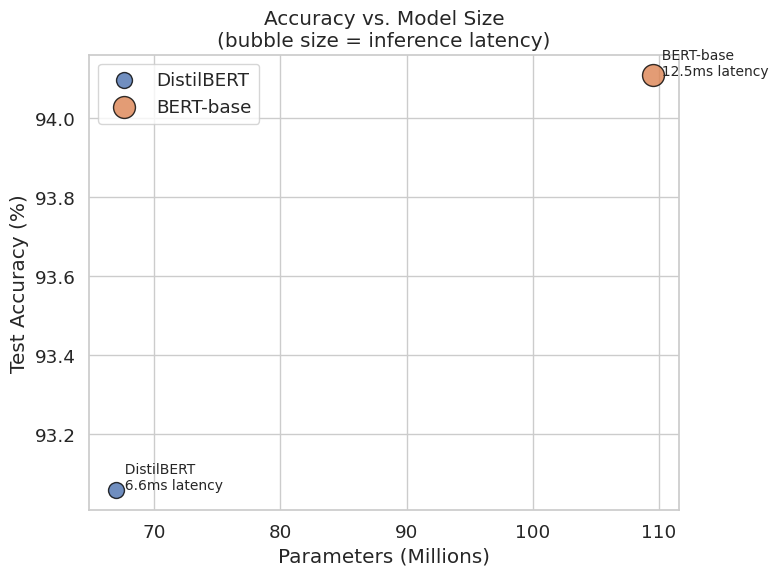

Saved: figures/06_accuracy_vs_size.png


In [ ]:
# Accuracy vs. Efficiency Scatter
fig, ax = plt.subplots(figsize=(8, 6))

for m in models_ordered:
    r = all_results[m]
    ax.scatter(
        r["n_params"] / 1e6,
        r["accuracy"] * 100,
        s=r["latency_ms"] * 20,  # bubble size = latency
        color=COLORS[m],
        alpha=0.8,
        edgecolors="black",
        label=DISPLAY_NAMES[m],
        zorder=3,
    )
    ax.annotate(
        f"  {DISPLAY_NAMES[m]}\n  {r['latency_ms']:.1f}ms latency",
        (r["n_params"] / 1e6, r["accuracy"] * 100),
        fontsize=10,
    )

ax.set_xlabel("Parameters (Millions)")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Accuracy vs. Model Size\n(bubble size = inference latency)")
ax.legend()

save_fig("06_accuracy_vs_size")

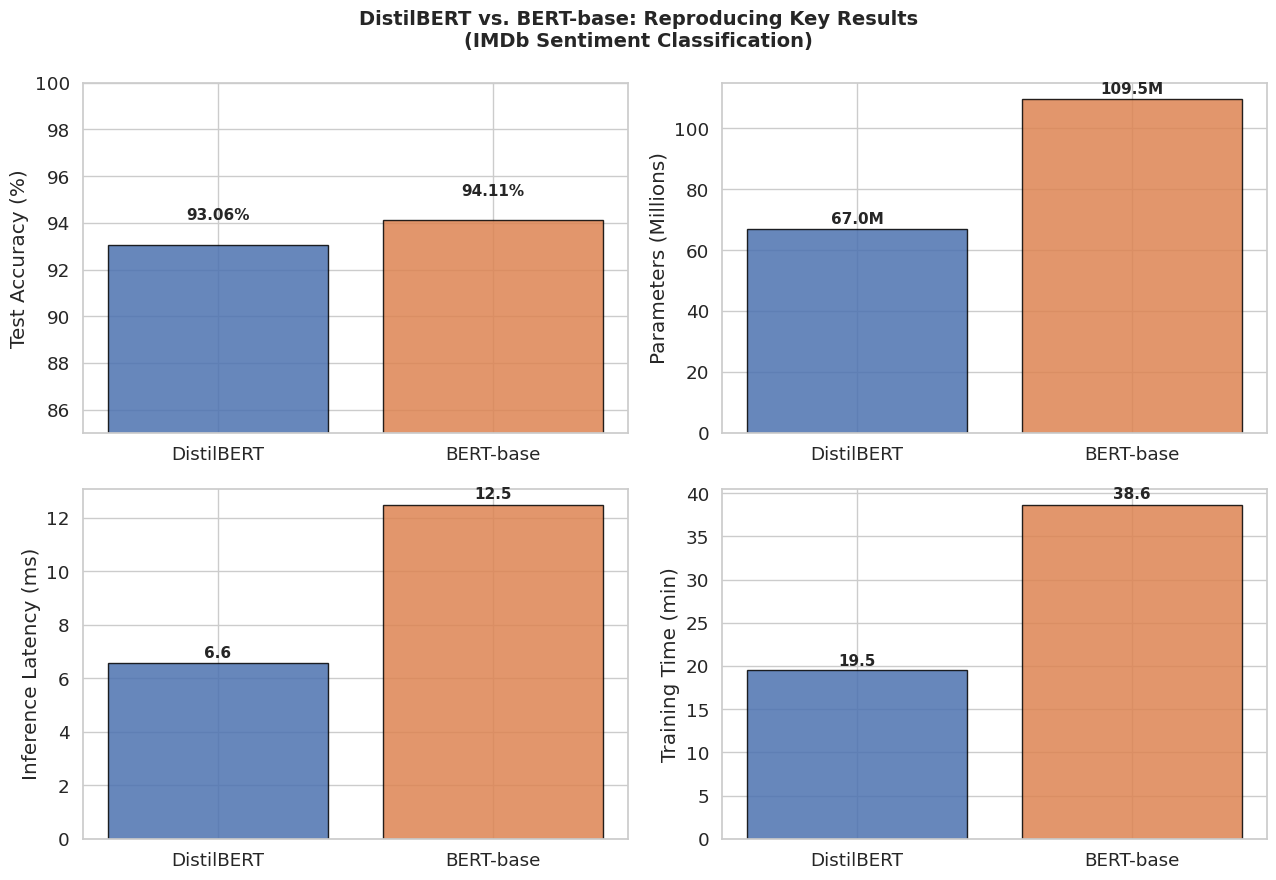

Saved: figures/08_summary_4panel.png


In [ ]:
# 4-panel Summary Figure
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("DistilBERT vs. BERT-base: Reproducing Key Results\n(IMDb Sentiment Classification)",
             fontsize=14, fontweight="bold")

panels = [
    (axes[0, 0], "Test Accuracy (%)", [r["accuracy"]*100 for r in [all_results[m] for m in models_ordered]], True),
    (axes[0, 1], "Parameters (Millions)", [all_results[m]["n_params"]/1e6  for m in models_ordered], False),
    (axes[1, 0], "Inference Latency (ms)", [all_results[m]["latency_ms"]    for m in models_ordered], False),
    (axes[1, 1], "Training Time (min)", [all_results[m]["train_time_sec"]/60 for m in models_ordered], False),
]

for ax, ylabel, values, is_acc in panels:
    bars = ax.bar(labels, values, color=bar_colors, edgecolor="black", alpha=0.85)
    ax.set_ylabel(ylabel)
    if is_acc:
        ax.set_ylim(85, 100)
    for bar, v in zip(bars, values):
        fmt = f"{v:.2f}%" if is_acc else (f"{v:.1f}M" if "Million" in ylabel else f"{v:.1f}")
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                fmt, ha="center", va="bottom", fontsize=11, fontweight="bold")

save_fig("08_summary_4panel")

In [ ]:
print("╔" + "═"*68 + "╗")
print("║" + " FINAL RESULTS SUMMARY ".center(68) + "║")
print("╠" + "═"*68 + "╣")
print(f"║  Dataset: IMDb Sentiment Classification ({SUBSET_TRAIN or 25000} train / {SUBSET_TEST or 25000} test)".ljust(69) + "║")
print(f"║  Training: {EPOCHS} epochs, lr=2e-5, max_len={MAX_LEN}, batch={BATCH_SIZE}, device={DEVICE.upper()}".ljust(69) + "║")
print("╠" + "═"*68 + "╣")
print(f"║  {'Metric':<30} {'DistilBERT':>14} {'BERT-base':>14} {'Ratio':>6}  ║")
print("╠" + "─"*68 + "╣")

rows = [
    ("IMDb Test Accuracy",      f"{distil['accuracy']*100:.2f}%",          f"{bert['accuracy']*100:.2f}%",          f"{acc_retention:.1f}%"),
    ("Parameters",              f"{distil['n_params']/1e6:.1f}M",          f"{bert['n_params']/1e6:.1f}M",          f"{100-param_reduction:.0f}%"),
    ("Model Size",              f"{distil['size_mb']:.0f} MB",             f"{bert['size_mb']:.0f} MB",             f"{100-size_reduction:.0f}%"),
    ("Inference Latency",       f"{distil['latency_ms']:.2f} ms",          f"{bert['latency_ms']:.2f} ms",          f"{1/speedup_factor*100:.0f}%"),
    ("Training Time",           f"{distil['train_time_sec']/60:.1f} min",  f"{bert['train_time_sec']/60:.1f} min",  f"{1/train_speedup*100:.0f}%"),
]
for row in rows:
    print(f"║  {row[0]:<30} {row[1]:>14} {row[2]:>14} {row[3]:>6}  ║")

print("╠" + "═"*68 + "╣")
print("║  Paper Claims (Table 2 & 3):                                       ║")
print("║    IMDb Test Accuracy:  DistilBERT 92.82%  vs  BERT 93.46%         ║")
print("║    Parameters:          66M  vs  110M  (40% fewer)                 ║")
print("║    Inference (CPU):     410s vs  668s  (60% faster)                ║")
print("╚" + "═"*68 + "╝")

print("\nAll figures saved to: figures/")
import glob
for f in sorted(glob.glob("figures/*.png")):
    print(f"  {f}")

╔════════════════════════════════════════════════════════════════════╗
║                       FINAL RESULTS SUMMARY                        ║
╠════════════════════════════════════════════════════════════════════╣
║  Dataset: IMDb Sentiment Classification (25000 train / 25000 test) ║
║  Training: 3 epochs, lr=2e-5, max_len=512, batch=32, device=CUDA   ║
╠════════════════════════════════════════════════════════════════════╣
║  Metric                             DistilBERT      BERT-base  Ratio  ║
╠────────────────────────────────────────────────────────────────────╣
║  IMDb Test Accuracy                     93.06%         94.11%  98.9%  ║
║  Parameters                              67.0M         109.5M    61%  ║
║  Model Size                             255 MB         418 MB    61%  ║
║  Inference Latency                     6.58 ms       12.46 ms    53%  ║
║  Training Time                        19.5 min       38.6 min    51%  ║
╠══════════════════════════════════════════════════════════